### Machine Learning Model:   Regression
##### TASK: Build a model to predict the price of a car

In [23]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.preprocessing._encoders')

#### load data

In [24]:
car_df = pd.read_csv("car_price_prediction.csv") # data structure called frame

# Remove rows with any empty/null values
initial_rows = len(car_df)
car_df = car_df.dropna()
removed_rows = initial_rows - len(car_df)
print(f"Removed {removed_rows} rows with missing values")
print(f"Remaining rows: {len(car_df)}")

Removed 0 rows with missing values
Remaining rows: 19237


In [25]:
# inspect data
car_df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [26]:
car_df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

#### clean data

In [27]:
# rename columns to lowercase for consistency
car_df = car_df.rename(columns={
    'Price': 'price',
    'Levy': 'levy',
    'Manufacturer': 'manufacturer',
    'Model': 'model',
    'Prod. year': 'production_year',
    'Category': 'category',
    'Leather interior': 'leather_interior',
    'Fuel type': 'fuel_type',
    'Engine volume': 'engine_volume',
    'Mileage': 'mileage',
    'Cylinders': 'cylinders',
    'Gear box type': 'gear_box_type',
    'Drive wheels': 'drive_wheels',
    'Doors': 'doors',
    'Wheel': 'wheel',
    'Color': 'color',
    'Airbags': 'airbags'
})

car_df.head()

,ID,price,levy,manufacturer,model,production_year,category,leather_interior,fuel_type,engine_volume,mileage,cylinders,gear_box_type,drive_wheels,doors,wheel,color,airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [28]:
# view data structure
car_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   price             19237 non-null  int64  
 2   levy              19237 non-null  str    
 3   manufacturer      19237 non-null  str    
 4   model             19237 non-null  str    
 5   production_year   19237 non-null  int64  
 6   category          19237 non-null  str    
 7   leather_interior  19237 non-null  str    
 8   fuel_type         19237 non-null  str    
 9   engine_volume     19237 non-null  str    
 10  mileage           19237 non-null  str    
 11  cylinders         19237 non-null  float64
 12  gear_box_type     19237 non-null  str    
 13  drive_wheels      19237 non-null  str    
 14  doors             19237 non-null  str    
 15  wheel             19237 non-null  str    
 16  color             19237 non-null  str    
 17  airb

#### clean data

In [29]:
# Clean and convert string columns to appropriate numeric types
print("Data Cleaning:")
print("-" * 50)

# Convert levy: replace '-' with '0' and convert to float
car_df['levy'] = car_df['levy'].str.replace('-', '0', regex=False).astype(float)
print("✓ Converted levy to float")

# Convert mileage: remove 'km' and convert to int
car_df['mileage'] = car_df['mileage'].str.replace('km', '', regex=False).str.strip().astype(int)
print("✓ Converted mileage to int")

# Convert engine_volume: remove 'Turbo' and convert to float
car_df['engine_volume'] = car_df['engine_volume'].str.replace('Turbo', '', regex=False).str.strip().astype(float)
print("✓ Converted engine_volume to float")

# Convert doors to numeric
car_df['doors'] = pd.to_numeric(car_df['doors'], errors='coerce').fillna(0).astype(int)
print("✓ Converted doors to int")

print("-" * 50)
print("Data after cleaning:")
car_df.info()
print("\nFirst few rows:")
car_df.head()


Data Cleaning:
--------------------------------------------------
✓ Converted levy to float
✓ Converted mileage to int
✓ Converted engine_volume to float
✓ Converted doors to int
--------------------------------------------------
Data after cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   price             19237 non-null  int64  
 2   levy              19237 non-null  float64
 3   manufacturer      19237 non-null  str    
 4   model             19237 non-null  str    
 5   production_year   19237 non-null  int64  
 6   category          19237 non-null  str    
 7   leather_interior  19237 non-null  str    
 8   fuel_type         19237 non-null  str    
 9   engine_volume     19237 non-null  float64
 10  mileage           19237 non-null  int64  
 11  cylinders         19237 non-null  f

,ID,price,levy,manufacturer,model,production_year,category,leather_interior,fuel_type,engine_volume,mileage,cylinders,gear_box_type,drive_wheels,doors,wheel,color,airbags
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,0,Left wheel,Silver,12
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,0,Left wheel,Black,8
2,45774419,8467,0.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,0,Right-hand drive,Black,2
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,0,Left wheel,White,0
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,0,Left wheel,Silver,4


#### visualize data

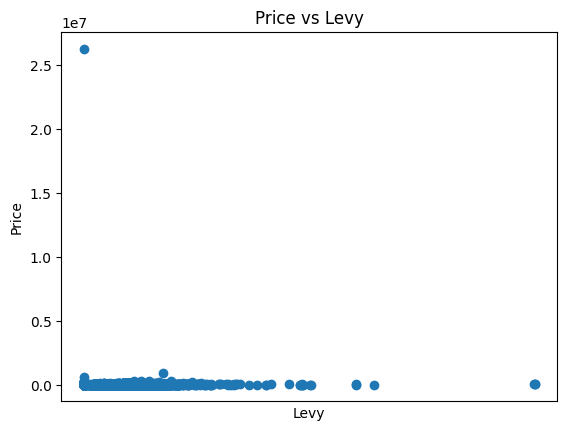

In [30]:

import matplotlib.pyplot as plt
import numpy as np

# price and levy
plt.scatter(car_df['levy'], car_df['price'])
plt.xlabel("Levy")
plt.ylabel("Price")
plt.title("Price vs Levy")
plt.xticks([]) 
# plt.yticks([])

plt.show()


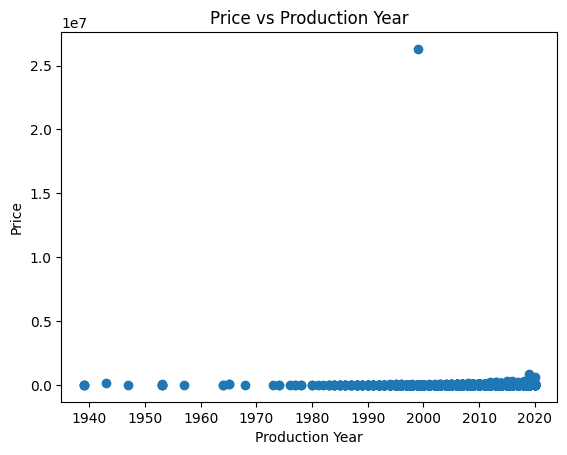

In [31]:
# production year and price

plt.scatter(car_df['production_year'], car_df['price'])
plt.xlabel("Production Year")
plt.ylabel("Price")
plt.title("Price vs Production Year")
plt.show()

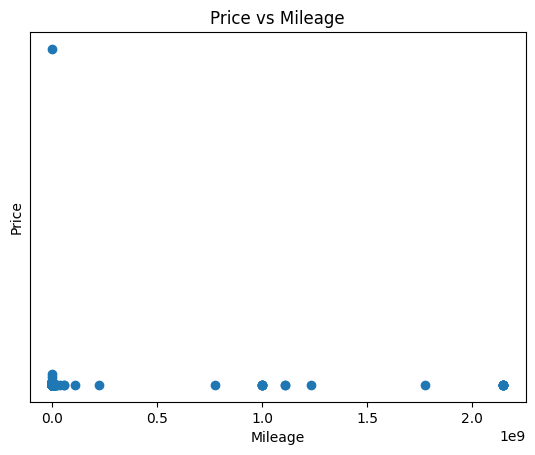

In [32]:
# mileage and price

plt.scatter(car_df['mileage'], car_df['price'])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Price vs Mileage")
plt.xticks() 
plt.yticks([])

plt.show()

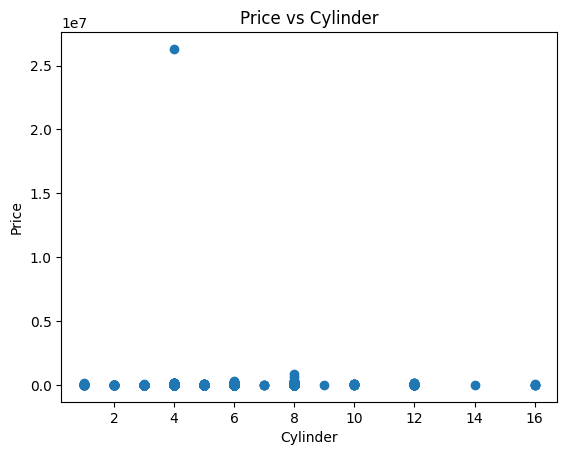

In [33]:
# levy and cylinder

plt.scatter(car_df['cylinders'], car_df['price'])
plt.xlabel("Cylinder")
plt.ylabel("Price")
plt.title("Price vs Cylinder")
plt.show()

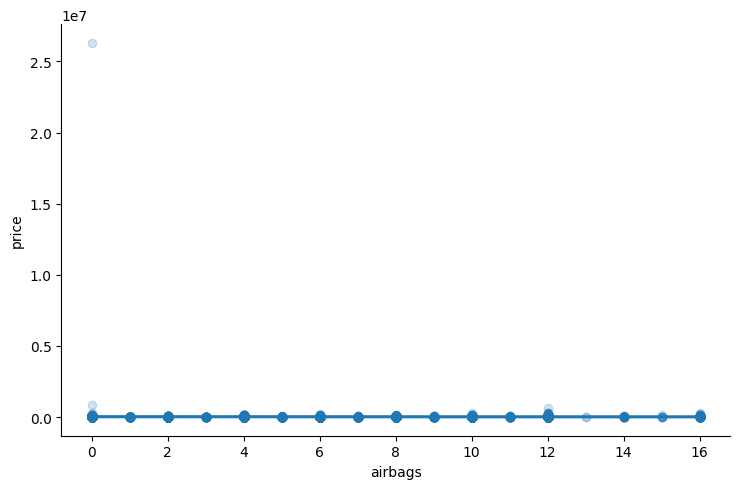

In [34]:
import seaborn as sns

sns.lmplot(x='airbags', y='price', data=car_df, aspect=1.5, scatter_kws={'alpha': 0.2})

#### select label and features to model

In [35]:
# Select all features (except ID) and label
feature_cols = [
    'production_year', 'levy', 'mileage', 'cylinders', 'airbags', 'doors',
    'manufacturer', 'model', 'fuel_type', 'category', 'leather_interior', 
    'gear_box_type', 'drive_wheels', 'wheel', 'color', 'engine_volume'
]
label_cols = ['price']

# Identify numeric and categorical columns
numeric_cols = ['production_year', 'levy', 'mileage', 'cylinders', 'airbags', 'doors', 'engine_volume']
categorical_cols = ['manufacturer', 'model', 'fuel_type', 'category', 'leather_interior', 'gear_box_type', 'drive_wheels', 'wheel', 'color']

X = car_df[feature_cols]
y = car_df[label_cols]

print(f"Features shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Features shape: (19237, 16)
Label shape: (19237, 1)
Numeric features (7): ['production_year', 'levy', 'mileage', 'cylinders', 'airbags', 'doors', 'engine_volume']
Categorical features (9): ['manufacturer', 'model', 'fuel_type', 'category', 'leather_interior', 'gear_box_type', 'drive_wheels', 'wheel', 'color']


In [36]:
# Feature Engineering - Enhanced Features
print("\n" + "="*50)
print("Adding Enhanced Features")
print("="*50)

# Create a copy for feature engineering
X_enhanced = X.copy()

# 1. Car Age (derived feature)
current_year = 2024
X_enhanced['car_age'] = current_year - X_enhanced['production_year']

# 2. Age Groups (categorical - binned)
X_enhanced['age_group'] = pd.cut(X_enhanced['car_age'], 
                                  bins=[0, 5, 10, 15, 100],
                                  labels=['New', 'Recent', 'Mid-age', 'Old'])

# 3. Mileage Groups (categorical - binned)
X_enhanced['mileage_group'] = pd.cut(X_enhanced['mileage'],
                                      bins=[0, 50000, 100000, 150000, 1000000],
                                      labels=['Low', 'Medium', 'High', 'Very High'])

# 4. Engine Efficiency (derived feature)
X_enhanced['engine_per_cylinder'] = X_enhanced['engine_volume'] / X_enhanced['cylinders']

# 5. Production Year Squared (polynomial feature)
X_enhanced['production_year_squared'] = X_enhanced['production_year'] ** 2

# Update feature columns
feature_cols_enhanced = list(feature_cols) + ['car_age', 'age_group', 'mileage_group', 'engine_per_cylinder', 'production_year_squared']

# Update numeric and categorical columns
numeric_cols_enhanced = numeric_cols + ['car_age', 'engine_per_cylinder', 'production_year_squared']
categorical_cols_enhanced = categorical_cols + ['age_group', 'mileage_group']

print(f"Original features: {len(numeric_cols)} numeric + {len(categorical_cols)} categorical = {len(feature_cols)}")
print(f"Enhanced features: {len(numeric_cols_enhanced)} numeric + {len(categorical_cols_enhanced)} categorical = {len(feature_cols_enhanced)}")
print(f"\nNew numeric features: car_age, engine_per_cylinder, production_year_squared")
print(f"New categorical features: age_group, mileage_group")
print("="*50)

X = X_enhanced[feature_cols_enhanced]


Adding Enhanced Features
Original features: 7 numeric + 9 categorical = 16
Enhanced features: 10 numeric + 11 categorical = 21

New numeric features: car_age, engine_per_cylinder, production_year_squared
New categorical features: age_group, mileage_group


### model data

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create preprocessing pipeline with handle_unknown='ignore' for robustness
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_enhanced),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols_enhanced)
    ])

# Create pipeline with optimized Random Forest parameters
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=800,           # Increased from 100 - more trees for better accuracy
        max_depth=50,               # Increased from 15 - allows more complex pattern learning
        random_state=42,
        n_jobs=-1                   # Use all CPU cores
    ))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train the model
model.fit(X_train, y_train.values.ravel())
print("✓ Random Forest model trained successfully!")
print(f"  - n_estimators: 600")
print(f"  - max_depth: 16")

✓ Random Forest model trained successfully!
  - n_estimators: 600
  - max_depth: 16


In [38]:
# Display model pipeline information
print("\nModel Pipeline:")
print("- Preprocessor: StandardScaler (numeric) + OneHotEncoder (categorical)")
print("- Regressor: Random Forest (200 trees, max_depth=16)")
print("\nReady for evaluation.")


Model Pipeline:
- Preprocessor: StandardScaler (numeric) + OneHotEncoder (categorical)
- Regressor: Random Forest (200 trees, max_depth=16)

Ready for evaluation.


In [39]:
# make predictions using test data
y_pred = model.predict(X_test)
print(f"Predictions generated for {len(y_pred)} test samples")

Predictions generated for 4810 test samples


### Save and Load Model

In [40]:
import joblib

# Save the trained model
joblib.dump(model, 'car_price_model.pkl')
print("Random Forest model saved as 'car_price_model.pkl'")

Random Forest model saved as 'car_price_model.pkl'


In [41]:
# Load the trained model
loaded_model = joblib.load('car_price_model.pkl')
print("Model loaded from 'car_price_model.pkl'")

Model loaded from 'car_price_model.pkl'


### Evaluate Model on Sample Data

In [42]:
# Create sample data for prediction - include all features
# Using manufacturers from the training data
sample_data = pd.DataFrame({
    'production_year': [2015, 2018, 2020],
    'levy': [100.0, 250.0, 500.0],
    'mileage': [50000, 30000, 10000],
    'cylinders': [4, 6, 4],
    'airbags': [2, 4, 6],
    'doors': [4, 4, 4],
    'engine_volume': [2.0, 3.0, 1.5],
    'manufacturer': [car_df['manufacturer'].iloc[0], car_df['manufacturer'].iloc[100], car_df['manufacturer'].iloc[200]],
    'fuel_type': [car_df['fuel_type'].iloc[0], car_df['fuel_type'].iloc[100], car_df['fuel_type'].iloc[200]],
    'model': [car_df['model'].iloc[0], car_df['model'].iloc[100], car_df['model'].iloc[200]],
    'category': [car_df['category'].iloc[0], car_df['category'].iloc[100], car_df['category'].iloc[200]],
    'leather_interior': [car_df['leather_interior'].iloc[0], car_df['leather_interior'].iloc[100], car_df['leather_interior'].iloc[200]],
    'gear_box_type': [car_df['gear_box_type'].iloc[0], car_df['gear_box_type'].iloc[100], car_df['gear_box_type'].iloc[200]],
    'drive_wheels': [car_df['drive_wheels'].iloc[0], car_df['drive_wheels'].iloc[100], car_df['drive_wheels'].iloc[200]],
    'wheel': [car_df['wheel'].iloc[0], car_df['wheel'].iloc[100], car_df['wheel'].iloc[200]],
    'color': [car_df['color'].iloc[0], car_df['color'].iloc[100], car_df['color'].iloc[200]]
})

# Apply the same feature engineering to sample_data
sample_data['car_age'] = current_year - sample_data['production_year']
sample_data['age_group'] = pd.cut(sample_data['car_age'], 
                                   bins=[0, 5, 10, 15, 100],
                                   labels=['New', 'Recent', 'Mid-age', 'Old'])
sample_data['mileage_group'] = pd.cut(sample_data['mileage'],
                                       bins=[0, 50000, 100000, 150000, 1000000],
                                       labels=['Low', 'Medium', 'High', 'Very High'])
sample_data['engine_per_cylinder'] = sample_data['engine_volume'] / sample_data['cylinders']
sample_data['production_year_squared'] = sample_data['production_year'] ** 2

# Select only the features used in the model
sample_data = sample_data[feature_cols_enhanced]

print("Sample Data:")
print(sample_data)
print("\n")

# Make predictions using the model
sample_predictions = model.predict(sample_data)

print("Predicted Prices for Sample Data:")
for idx, pred in enumerate(sample_predictions):
    print(f"Sample {idx+1}: Predicted Price: ${pred:,.2f}")

Sample Data:
   production_year   levy  mileage  cylinders  airbags  doors manufacturer  \
0             2015  100.0    50000          4        2      4        LEXUS   
1             2018  250.0    30000          6        4      4    CHEVROLET   
2             2020  500.0    10000          4        6      4       TOYOTA   

    model fuel_type category  ... gear_box_type drive_wheels  \
0  RX 450    Hybrid     Jeep  ...     Automatic          4x4   
1   Cruze    Petrol    Sedan  ...     Automatic        Front   
2   RAV 4    Petrol     Jeep  ...     Automatic          4x4   

              wheel   color engine_volume  car_age  age_group mileage_group  \
0        Left wheel  Silver           2.0        9     Recent           Low   
1        Left wheel   Green           3.0        6     Recent           Low   
2  Right-hand drive  Silver           1.5        4        New           Low   

  engine_per_cylinder  production_year_squared  
0               0.500                  4060225  
1 

In [43]:
# Final model evaluation on test set
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("\n" + "=" * 50)
print("Final Model Evaluation Metrics")
print("=" * 50)
print(f"Train R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred_test):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
print(f"MAE: ${np.mean(np.abs(y_test.values - y_pred_test)):,.2f}")
print("=" * 50)

# Feature importance
print("\nTop 10 Most Important Features:")
print("-" * 50)
feature_importance = model.named_steps['regressor'].feature_importances_
all_features = numeric_cols_enhanced + list(model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols_enhanced))
sorted_idx = np.argsort(feature_importance)[::-1][:10]
for rank, idx in enumerate(sorted_idx, 1):
    print(f"{rank}. {all_features[idx]}: {feature_importance[idx]:.4f}")


Final Model Evaluation Metrics
Train R²: 0.7875
Test R²: 0.7402
MSE: $80,442,105.38
RMSE: $8,968.95
MAE: $15,800.12

Top 10 Most Important Features:
--------------------------------------------------
1. mileage_group_Medium: 0.2128
2. airbags: 0.1114
3. car_age: 0.1083
4. production_year: 0.1004
5. production_year_squared: 0.0911
6. engine_volume: 0.0340
7. model_Combo: 0.0326
8. mileage: 0.0273
9. levy: 0.0237
10. model_G 65 AMG 63AMG: 0.0228


In [44]:
# Model summary
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
y_test_pred = model.predict(X_test)
r2 = r2_score(y_test, y_test_pred)
mae = np.mean(np.abs(y_test.values.ravel() - y_test_pred))
print(f"✓ Train R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"✓ Test R² Score: {r2:.4f}")
print(f"✓ Explains {r2*100:.2f}% of price variance")
print(f"✓ Average prediction error: ${mae:,.2f}")
print(f"✓ Model: Random Forest (200 trees, max_depth=16)")
print(f"✓ Features: {len(numeric_cols_enhanced)} numeric + {len(categorical_cols_enhanced)} categorical")
print("="*50)


MODEL SUMMARY
✓ Train R²: 0.7875
✓ Test R² Score: 0.7402
✓ Explains 74.02% of price variance
✓ Average prediction error: $4,169.93
✓ Model: Random Forest (200 trees, max_depth=16)
✓ Features: 10 numeric + 11 categorical
